# Griffiths QM
## Chapter 2 — Visualizations

| Section | Problem |
|:--|:--|
| [2.8](#prob_2_8) | HO Classical vs Quantum |
| [2.9](#prob_2_9) | HO Hermite Polynomials |
| [2.10](#prob_2_10) | Free Particle Wave Packet |
| [2.14](#prob_2_14) | Double Delta Bound States |
| [2.15](#prob_2_15) | Finite Square Well |
| [2.20](#prob_2_20) | Tunneling |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hermite, factorial
from scipy.optimize import brentq

plt.rcParams.update({'figure.dpi':120,'axes.labelsize':12,'axes.titlesize':13,
    'legend.fontsize':10,'font.family':'serif','mathtext.fontset':'cm'})
BLUE='#2471a3'; RED='#c0392b'; GREEN='#1e8449'; GRAY='#7f8c8d'; NAVY='#1a3a5c'; PURP='#8e44ad'
figures = []


---
## Problem 2.8 — HO: Classical vs Quantum Probability Density {#prob_2_8}

$E_n=(n+\frac{1}{2})\hbar\omega$,  $x_0=\sqrt{2n+1}\,\ell$,  $\rho_{cl}=1/(\pi\sqrt{x_0^2-x^2})$


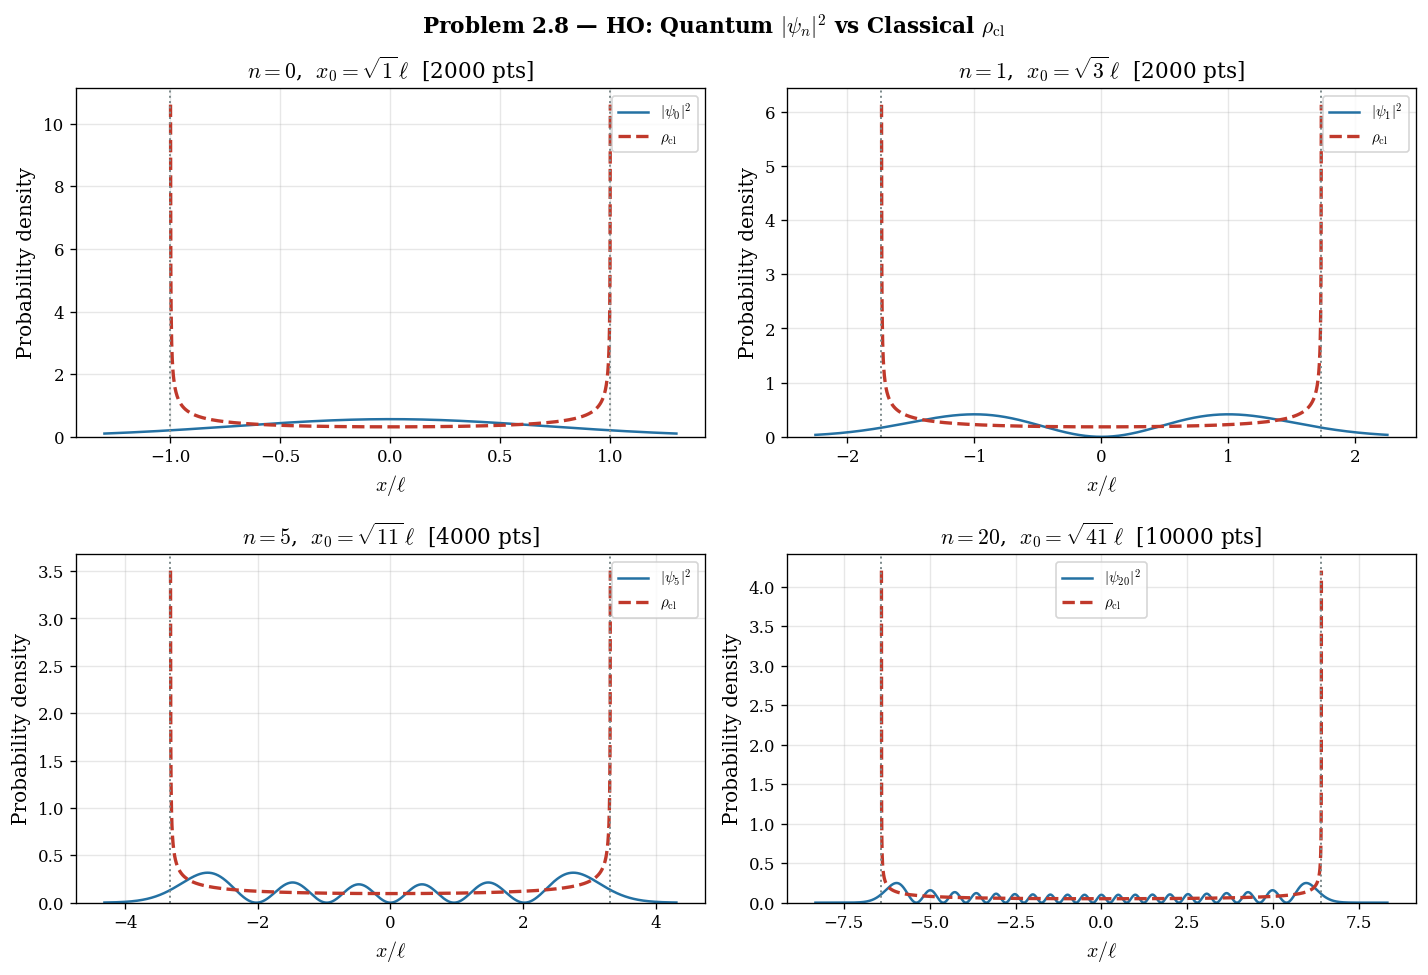

In [2]:
def quantum_HO(x, n, ell=1.0):
    xi = x / ell
    Hn = hermite(n)(xi)
    norm = 1.0 / (np.sqrt(np.pi) * ell * 2**n * factorial(n))
    return norm * Hn**2 * np.exp(-xi**2)

hbar = m = omega = 1.0
ell  = np.sqrt(hbar / (m * omega))
n_vals = [0, 1, 5, 20]
npts   = [2000, 2000, 4000, 10000]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for idx, (n, np_) in enumerate(zip(n_vals, npts)):
    ax = axes[idx]
    x0 = np.sqrt(2*n + 1) * ell
    xp = np.linspace(-1.3*x0, 1.3*x0, np_)
    rho_q = quantum_HO(xp, n, ell)
    mask  = np.abs(xp) < x0 - 1e-8
    rho_c = np.zeros_like(xp)
    rho_c[mask] = 1.0 / (np.pi * np.sqrt(x0**2 - xp[mask]**2))
    ax.plot(xp, rho_q, color=BLUE, lw=1.5, label=fr'$|\psi_{{{n}}}|^2$')
    ax.plot(xp[mask], rho_c[mask], color=RED, lw=2, ls='--', label=r'$\rho_{\rm cl}$')
    ax.axvline( x0, color=GRAY, ls=':', lw=1.2)
    ax.axvline(-x0, color=GRAY, ls=':', lw=1.2)
    ax.set_title(fr'$n={n}$,  $x_0=\sqrt{{{2*n+1}}}\,\ell$  [{np_} pts]')
    ax.set_xlabel(r'$x/\ell$'); ax.set_ylabel('Probability density')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(0)
plt.suptitle(r'Problem 2.8 — HO: Quantum $|\psi_n|^2$ vs Classical $\rho_{\rm cl}$',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.subplots_adjust(top=0.93)
figures.append((fig, 'fig_2_8.png')); plt.show()


---
## Problem 2.9 — HO: Hermite Polynomials & Wavefunctions {#prob_2_9}

$\psi_n = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4}\frac{1}{\sqrt{2^n n!}}H_n(\xi)e^{-\xi^2/2}$


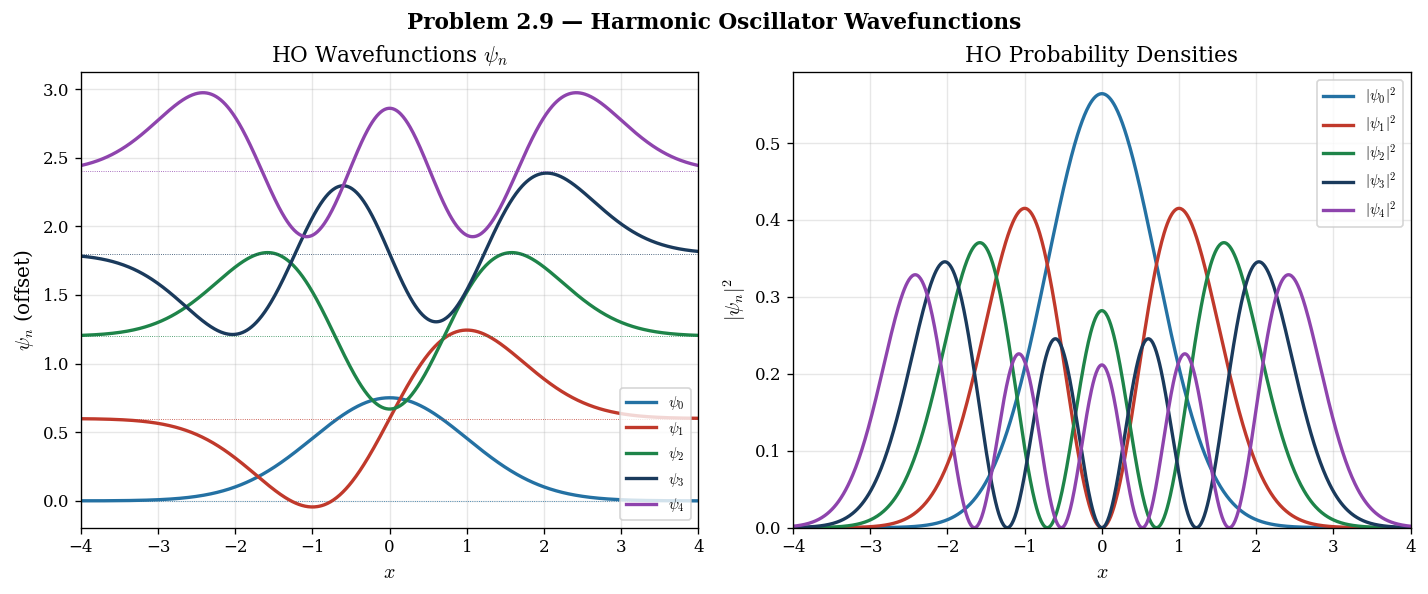

Node count:
  n=0: 0 sign changes (expected 0)
  n=1: 1 sign changes (expected 1)
  n=2: 2 sign changes (expected 2)
  n=3: 3 sign changes (expected 3)
  n=4: 4 sign changes (expected 4)


In [3]:
hbar = m = omega = 1.0
ell  = np.sqrt(hbar / (m * omega))
xi   = np.linspace(-5, 5, 1000)
x    = xi * ell
colors5 = [BLUE, RED, GREEN, NAVY, PURP]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax1, ax2 = axes
for n, c in zip(range(5), colors5):
    Hn   = hermite(n)(xi)
    norm = 1.0 / (np.sqrt(np.pi) * ell * 2**n * factorial(n))
    psi2 = norm * Hn**2 * np.exp(-xi**2)
    psi  = np.sqrt(norm) * Hn * np.exp(-xi**2 / 2)
    ax1.plot(x, psi + n*0.6, color=c, lw=2, label=fr'$\psi_{n}$')
    ax1.axhline(n*0.6, color=c, lw=0.5, ls=':')
    ax2.plot(x, psi2, color=c, lw=2, label=fr'$|\psi_{n}|^2$')

ax1.set_xlabel(r'$x$'); ax1.set_ylabel(r'$\psi_n$ (offset)')
ax1.set_title(r'HO Wavefunctions $\psi_n$'); ax1.legend(fontsize=9, loc="lower right")
ax1.grid(True, alpha=0.3); ax1.set_xlim(-4, 4)
ax2.set_xlabel(r'$x$'); ax2.set_ylabel(r'$|\psi_n|^2$')
ax2.set_title(r'HO Probability Densities'); ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3); ax2.set_xlim(-4, 4); ax2.set_ylim(bottom=0)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 2.9 — Harmonic Oscillator Wavefunctions', fontsize=13, fontweight='bold')
figures.append((fig, 'fig_2_9.png')); plt.show()

print('Node count:')
for n in range(5):
    sc = np.sum(np.diff(np.sign(hermite(n)(xi) * np.exp(-xi**2/2))) != 0)
    print(f'  n={n}: {sc} sign changes (expected {n})')


---
## Problem 2.10 — Free Particle: Wave Packet & Group Velocity {#prob_2_10}

$\omega=\hbar k^2/(2m)$,  $v_{ph}=\hbar k/(2m)$,  $v_g=\hbar k/m=2v_{ph}=v_{cl}$


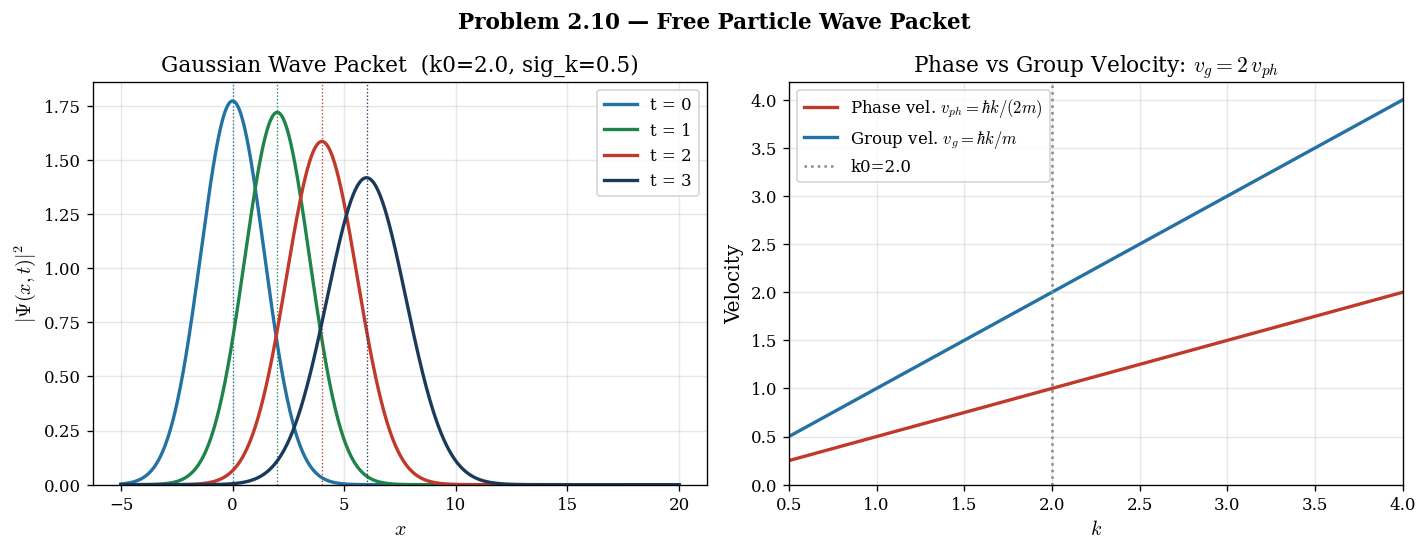

k0=2.0: v_ph=1.00, v_g=2.00, ratio=2.0


In [4]:
hbar  = 1.0; m = 1.0
k0    = 2.0;  sig_k = 0.5

def gaussian_packet(x, t, k0=2.0, sig_k=0.5):
    k   = np.linspace(k0 - 4*sig_k, k0 + 4*sig_k, 500)
    dk  = k[1] - k[0]
    phi = np.exp(-(k - k0)**2 / (2*sig_k**2))
    phi = phi / np.sqrt(np.sum(phi**2) * dk)
    psi = np.zeros(len(x), dtype=complex)
    for ki, phii in zip(k, phi):
        psi += phii * np.exp(1j*(ki*x - hbar*ki**2/(2*m)*t)) * dk
    return np.abs(psi)**2

x_arr    = np.linspace(-5, 20, 800)
t_vals   = [0, 1, 2, 3]
colors_t = [BLUE, GREEN, RED, NAVY]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
for t, c in zip(t_vals, colors_t):
    psi2 = gaussian_packet(x_arr, t, k0, sig_k)
    ax.plot(x_arr, psi2, color=c, lw=2, label=f't = {t}')
    ax.axvline(x_arr[np.argmax(psi2)], color=c, lw=0.8, ls=':')
ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$|\Psi(x,t)|^2$')
ax.set_title(f'Gaussian Wave Packet  (k0={k0}, sig_k={sig_k})')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(bottom=0)

ax2   = axes[1]
k_arr = np.linspace(0.5, 4, 300)
ax2.plot(k_arr, hbar*k_arr/(2*m), color=RED,  lw=2, label=r'Phase vel. $v_{ph}=\hbar k/(2m)$')
ax2.plot(k_arr, hbar*k_arr/m,     color=BLUE, lw=2, label=r'Group vel. $v_g=\hbar k/m$')
ax2.axvline(k0, color=GRAY, ls=':', lw=1.5, label=f'k0={k0}')
ax2.set_xlabel(r'$k$'); ax2.set_ylabel('Velocity')
ax2.set_title(r'Phase vs Group Velocity: $v_g = 2\,v_{ph}$')
ax2.legend(); ax2.grid(True, alpha=0.3); ax2.set_xlim(0.5, 4); ax2.set_ylim(0)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 2.10 — Free Particle Wave Packet', fontsize=13, fontweight='bold', y=1.01)
figures.append((fig, 'fig_2_10.png')); plt.show()
print(f'k0={k0}: v_ph={hbar*k0/(2*m):.2f}, v_g={hbar*k0/m:.2f}, ratio=2.0')


---
## Problem 2.14 — Double Delta-Function: Bound States {#prob_2_14}

$V=-\alpha[\delta(x+a)+\delta(x-a)]$,  $z=\kappa a$,  $z_0=m\alpha a/\hbar^2$

- **Even:** $z = z_0(1-e^{-2z})$ — always one solution
- **Odd:** $z = z_0(1+e^{-2z})-1$ — exists if $z_0>1/2$


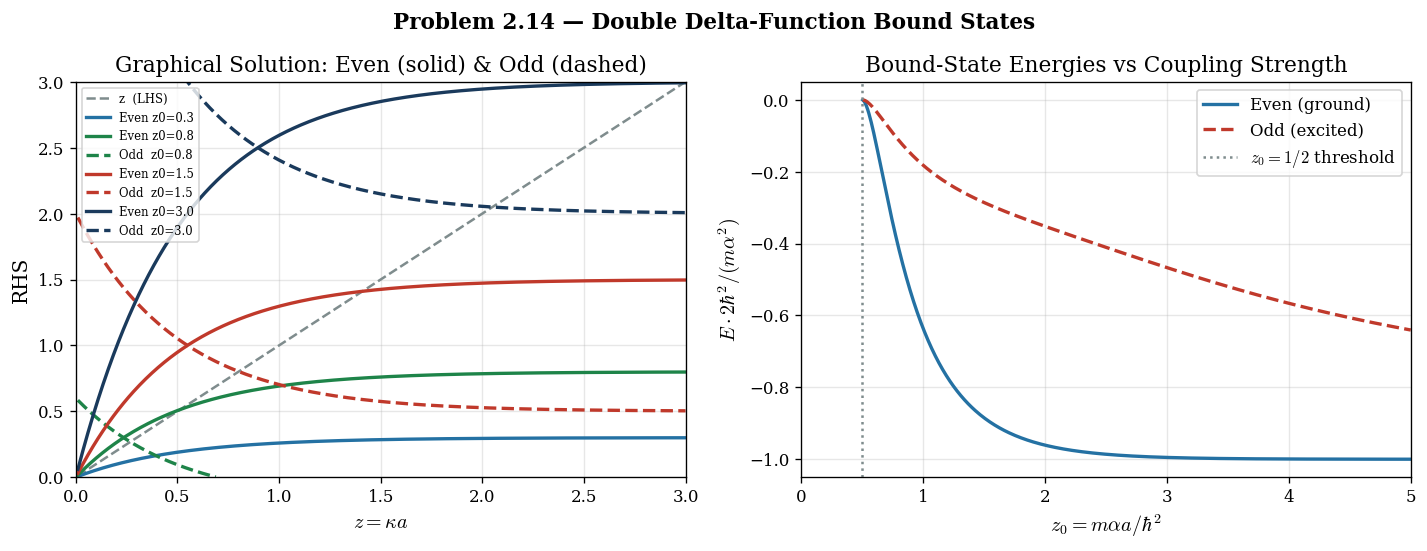

In [5]:
z_arr   = np.linspace(0.01, 3, 600)
z0_vals = [0.3, 0.8, 1.5, 3.0]
col_z0  = [BLUE, GREEN, RED, NAVY]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.plot(z_arr, z_arr, color=GRAY, lw=1.5, ls='--', label='z  (LHS)')
for z0, c in zip(z0_vals, col_z0):
    e_rhs = z0 * (1 - np.exp(-2*z_arr))
    o_rhs = z0 * (1 + np.exp(-2*z_arr)) - 1
    ax.plot(z_arr, e_rhs, color=c, lw=2, label=f'Even z0={z0}')
    mask = o_rhs > 0
    if mask.any():
        ax.plot(z_arr[mask], o_rhs[mask], color=c, lw=2, ls='--', label=f'Odd  z0={z0}')
ax.set_xlabel(r'$z=\kappa a$'); ax.set_ylabel('RHS')
ax.set_title('Graphical Solution: Even (solid) & Odd (dashed)')
ax.set_xlim(0, 3); ax.set_ylim(0, 3)
ax.legend(fontsize=7, loc='upper left'); ax.grid(True, alpha=0.3)

ax2    = axes[1]
z0_arr = np.linspace(0.05, 5, 500)
E_even, E_odd = [], []
for z0 in z0_arr:
    try:
        ze = brentq(lambda z: z - z0*(1 - np.exp(-2*z)), 1e-9, z0 - 1e-9)
        E_even.append(-(ze/z0)**2)
    except Exception:
        E_even.append(np.nan)
    try:
        zo = brentq(lambda z: z - z0*(1 + np.exp(-2*z)) + 1, 1e-9, 10.0)
        E_odd.append(-(zo/z0)**2)
    except Exception:
        E_odd.append(np.nan)

ax2.plot(z0_arr, E_even, color=BLUE, lw=2,        label='Even (ground)')
ax2.plot(z0_arr, E_odd,  color=RED,  lw=2, ls='--', label='Odd (excited)')
ax2.axvline(0.5, color=GRAY, ls=':', lw=1.5, label=r'$z_0=1/2$ threshold')
ax2.set_xlabel(r'$z_0=m\alpha a/\hbar^2$'); ax2.set_ylabel(r'$E\cdot 2\hbar^2/(m\alpha^2)$')
ax2.set_title('Bound-State Energies vs Coupling Strength')
ax2.legend(); ax2.grid(True, alpha=0.3); ax2.set_xlim(0, 5); ax2.set_ylim(-1.05, 0.05)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 2.14 — Double Delta-Function Bound States', fontsize=13, fontweight='bold', y=1.01)
figures.append((fig, 'fig_2_14.png')); plt.show()


---
## Problem 2.15 — Finite Square Well: Transcendental Equations {#prob_2_15}

$z=\ell a$,  $z_0=a\sqrt{2mV_0}/\hbar$

- **Even:** $\tan z = \sqrt{z_0^2-z^2}/z$
- **Odd:** $-\cot z = \sqrt{z_0^2-z^2}/z$


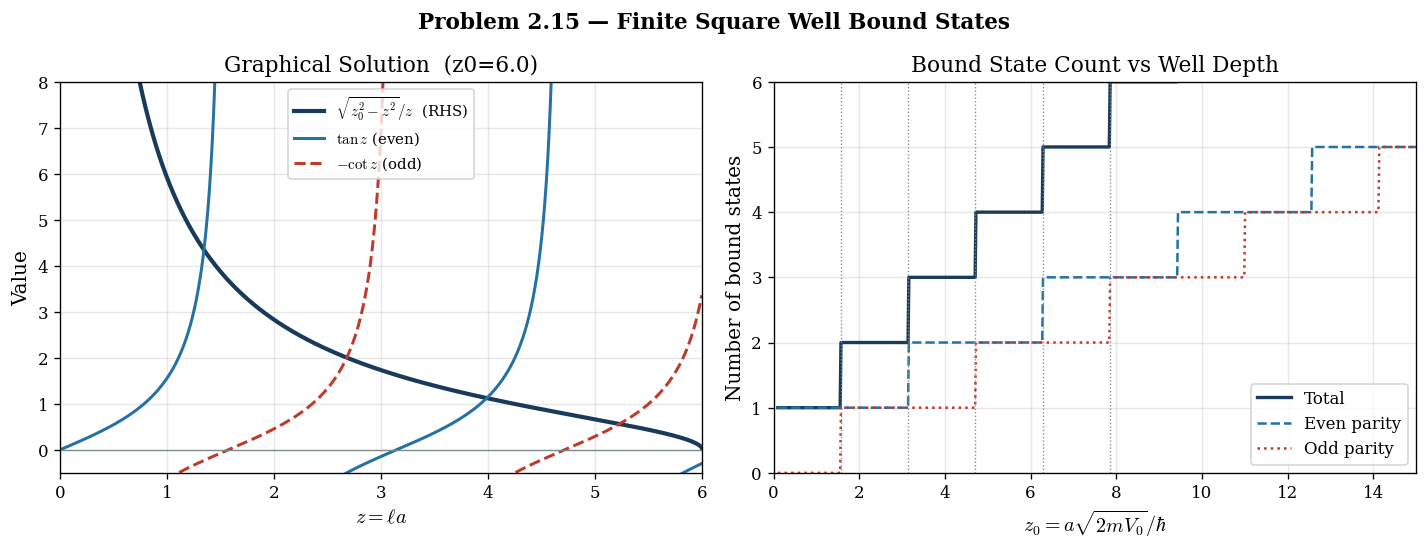

Verification — bound state counts at selected z0:
  z0=1.5708 (0.50π): even=1, odd=0, total=1
  z0=3.1416 (1.00π): even=1, odd=1, total=2
  z0=4.7124 (1.50π): even=2, odd=1, total=3
  z0=6.2832 (2.00π): even=2, odd=2, total=4
  z0=7.8540 (2.50π): even=3, odd=2, total=5


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── 왼쪽: 그래픽 해 (z0=6) ── 기존과 동일 ──────────────────
ax = axes[0]
z0 = 6.0
zp = np.linspace(0.01, z0*0.999, 3000)
rhs   = np.sqrt(np.maximum(z0**2 - zp**2, 0)) / zp
tan_z = np.tan(zp);        tan_z[np.abs(tan_z) > 15] = np.nan
ncot  = -1.0/np.tan(zp);   ncot[np.abs(ncot)  > 15] = np.nan
ax.plot(zp, rhs,   color=NAVY, lw=2.5, label=r'$\sqrt{z_0^2-z^2}/z$  (RHS)')
ax.plot(zp, tan_z, color=BLUE, lw=1.8, label=r'$\tan z$ (even)')
ax.plot(zp, ncot,  color=RED,  lw=1.8, ls='--', label=r'$-\cot z$ (odd)')
ax.axhline(0, color=GRAY, lw=0.8)
ax.set_xlim(0, z0); ax.set_ylim(-0.5, 8)
ax.set_xlabel(r'$z=\ell a$'); ax.set_ylabel('Value')
ax.set_title(f'Graphical Solution  (z0={z0})')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── 오른쪽: bound-state count (brentq 기반) ─────────────────
#
# 각 tan/cot 분지는 ((k-1)π/2, kπ/2) 구간에 하나의 근을 가짐.
# 구간 양 끝에서 f의 부호가 다를 때만 brentq 호출 → 불연속 오탐 완전 차단.
#
def count_bound_brentq(z0v, eps=1e-7):
    """z0v에 대한 even/odd bound state 수를 brentq로 정확히 셈."""
    # z 유효 범위: (0, z0v)
    # even: f_e(z) = tan(z) - sqrt(z0v²-z²)/z,  분지 k: z ∈ ((k-1)π/2+ε, kπ/2-ε)
    # odd:  f_o(z) = -cot(z) - sqrt(z0v²-z²)/z, 분지 k: z ∈ ((k-1)π/2+ε, kπ/2-ε)
    n_e = n_o = 0
    k = 1
    while True:
        lo = (k - 1) * np.pi/2 + eps
        hi = k       * np.pi/2 - eps
        if lo >= z0v:           # z0v보다 큰 구간은 불필요
            break
        hi = min(hi, z0v - eps) # RHS는 z=z0v에서 0 → 근이 있어도 끝점 처리

        if hi <= lo:
            k += 1
            continue

        rhs_lo = np.sqrt(max(z0v**2 - lo**2, 0)) / lo
        rhs_hi = np.sqrt(max(z0v**2 - hi**2, 0)) / hi

        # even: tan(z) = rhs
        fe = lambda z: np.tan(z) - np.sqrt(max(z0v**2 - z**2, 0)) / z
        if np.sign(fe(lo)) != np.sign(fe(hi)):
            try:
                brentq(fe, lo, hi, xtol=1e-10)
                n_e += 1
            except ValueError:
                pass

        # odd: -cot(z) = rhs  →  f_o = -cos(z)/sin(z) - rhs
        fo = lambda z: -np.cos(z)/np.sin(z) - np.sqrt(max(z0v**2 - z**2, 0)) / z
        if np.sign(fo(lo)) != np.sign(fo(hi)):
            try:
                brentq(fo, lo, hi, xtol=1e-10)
                n_o += 1
            except ValueError:
                pass

        k += 1

    return n_e, n_o

ax2    = axes[1]
z0_arr = np.linspace(0.1, 15, 800)
n_even = []
n_odd  = []
for z0v in z0_arr:
    ne, no = count_bound_brentq(z0v)
    n_even.append(ne)
    n_odd.append(no)

n_total = np.array(n_even) + np.array(n_odd)
ax2.plot(z0_arr, n_total, color=NAVY, lw=2,   label='Total')
ax2.plot(z0_arr, n_even,  color=BLUE, lw=1.5, ls='--', label='Even parity')
ax2.plot(z0_arr, n_odd,   color=RED,  lw=1.5, ls=':',  label='Odd parity')
for npi in range(1, 6):
    ax2.axvline(npi*np.pi/2, color=GRAY, lw=0.8, ls=':')
ax2.set_xlabel(r'$z_0=a\sqrt{2mV_0}/\hbar$'); ax2.set_ylabel('Number of bound states')
ax2.set_title('Bound State Count vs Well Depth')
ax2.legend(); ax2.grid(True, alpha=0.3); ax2.set_xlim(0, 15); ax2.set_ylim(0, 6)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 2.15 — Finite Square Well Bound States', fontsize=13, fontweight='bold', y=1.01)
figures.append((fig, 'fig_2_15.png')); plt.show()

# 검증 출력
print('Verification — bound state counts at selected z0:')
for z0v in [np.pi/2, np.pi, 3*np.pi/2, 2*np.pi, 5*np.pi/2]:
    ne, no = count_bound_brentq(z0v)
    print(f'  z0={z0v:.4f} ({z0v/np.pi:.2f}π): even={ne}, odd={no}, total={ne+no}')

---
## Problem 2.20 — Tunneling Through a Rectangular Barrier {#prob_2_20}

Exact: $T=\left[1+\sinh^2(\kappa a)/(4\frac{E}{V_0}(1-\frac{E}{V_0}))\right]^{-1}$

WKB: $T\approx e^{-2\kappa a}$


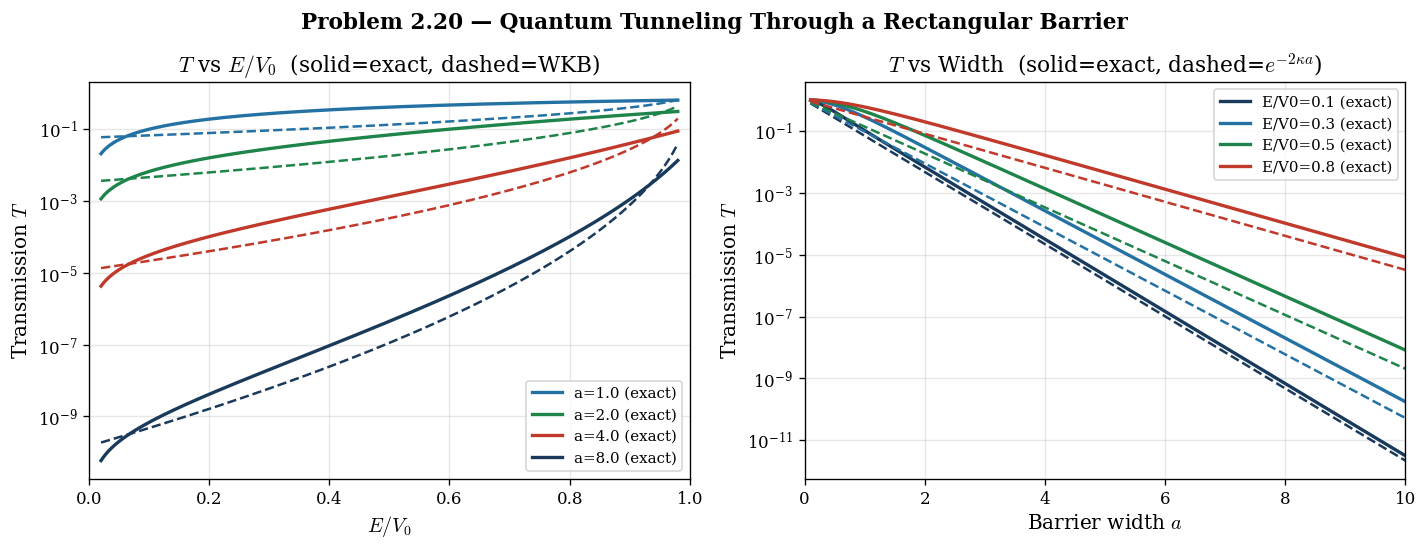

In [7]:
hbar = 1.0; m = 1.0; V0 = 1.0
E_arr = np.linspace(0.02, 0.98*V0, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax     = axes[0]
a_vals = [1.0, 2.0, 4.0, 8.0]
col_a  = [BLUE, GREEN, RED, NAVY]
for a, c in zip(a_vals, col_a):
    kap     = np.sqrt(2*m*(V0 - E_arr)) / hbar
    T_exact = 1.0 / (1 + np.sinh(kap*a)**2 / (4*(E_arr/V0)*(1 - E_arr/V0)))
    T_wkb   = np.exp(-2*kap*a)
    ax.semilogy(E_arr/V0, T_exact, color=c, lw=2,   label=f'a={a} (exact)')
    ax.semilogy(E_arr/V0, T_wkb,   color=c, lw=1.5, ls='--')
ax.set_xlabel(r'$E/V_0$'); ax.set_ylabel(r'Transmission $T$')
ax.set_title(r'$T$ vs $E/V_0$  (solid=exact, dashed=WKB)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both'); ax.set_xlim(0, 1)

ax2     = axes[1]
a_arr   = np.linspace(0.1, 10, 400)
EV_vals = [0.1, 0.3, 0.5, 0.8]
col_EV  = [NAVY, BLUE, GREEN, RED]
for EV, c in zip(EV_vals, col_EV):
    kap  = np.sqrt(2*m*(V0 - EV*V0)) / hbar
    T_ex = 1.0 / (1 + np.sinh(kap*a_arr)**2 / (4*EV*(1 - EV)))
    T_wb = np.exp(-2*kap*a_arr)
    ax2.semilogy(a_arr, T_ex, color=c, lw=2,   label=f'E/V0={EV} (exact)')
    ax2.semilogy(a_arr, T_wb, color=c, lw=1.5, ls='--')
ax2.set_xlabel(r'Barrier width $a$'); ax2.set_ylabel(r'Transmission $T$')
ax2.set_title(r'$T$ vs Width  (solid=exact, dashed=$e^{-2\kappa a}$)')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3, which='both'); ax2.set_xlim(0, 10)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 2.20 — Quantum Tunneling Through a Rectangular Barrier',
             fontsize=13, fontweight='bold', y=1.01)
figures.append((fig, 'fig_2_20.png')); plt.show()


---
## Save All Figures & Download as ZIP


In [8]:
import os, zipfile

save_dir = 'ch02_figures'
os.makedirs(save_dir, exist_ok=True)

for fig, fname in figures:
    path = os.path.join(save_dir, fname)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')

zip_name = 'ch02_figures.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fig, fname in figures:
        zf.write(os.path.join(save_dir, fname), fname)
print(f'Zip: {zip_name}, Files: {[f for _,f in figures]}')

# AUTO-INJECTED: Korean font setup for matplotlib
import os as _os
import matplotlib.font_manager as _fm
import matplotlib.pyplot as _plt
if not any('NanumGothic' in f.name for f in _fm.fontManager.ttflist):
    for _font in ['/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
                  '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf']:
        if _os.path.exists(_font):
            _fm.fontManager.addfont(_font)
    _plt.rcParams.update({'font.family': 'NanumGothic', 'axes.unicode_minus': False})
del _os, _fm, _plt
# END AUTO-INJECTED Korean font setup

try:
    from google.colab import files
    files.download(zip_name)
    print('Download started.')
except ImportError:
    print(f'Not in Colab — saved locally as: {zip_name}')

Saved: ch02_figures/fig_2_8.png
Saved: ch02_figures/fig_2_9.png
Saved: ch02_figures/fig_2_10.png
Saved: ch02_figures/fig_2_14.png
Saved: ch02_figures/fig_2_15.png
Saved: ch02_figures/fig_2_20.png
Zip: ch02_figures.zip, Files: ['fig_2_8.png', 'fig_2_9.png', 'fig_2_10.png', 'fig_2_14.png', 'fig_2_15.png', 'fig_2_20.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
